# Host Tie-In Capacity and Holdback

This notebook demonstrates the host tie-in capacity planner for a brownfield satellite tieback. It combines nameplate ullage, process-equipment capacity constraints, deferred production, and a first-pass debottleneck decision.

In [1]:
import importlib.util
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
DEVTOOLS_DIR = PROJECT_ROOT / "devtools"
sys.path.insert(0, str(DEVTOOLS_DIR))

setup_path = DEVTOOLS_DIR / "neqsim_dev_setup.py"
setup_spec = importlib.util.spec_from_file_location("neqsim_dev_setup", setup_path)
if setup_spec is None or setup_spec.loader is None:
    raise RuntimeError(f"Could not load devtools setup module from {setup_path}")
setup_module = importlib.util.module_from_spec(setup_spec)
setup_spec.loader.exec_module(setup_module)

neqsim_init = setup_module.neqsim_init
neqsim_classes = setup_module.neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
NEQSIM_MODE = "devtools"
NOTEBOOK_DIR = (PROJECT_ROOT / "examples" / "notebooks").resolve()
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print("NeqSim loaded via devtools workspace classes")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.25.4\log4j-api-2.25.4.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.25.4\log4j-core-2.25.4.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.44.0\ejml-all-0.44.0.jar
  12

In [2]:
import jpype
import matplotlib.pyplot as plt
import pandas as pd

HostFacility = ns.JClass("neqsim.process.fielddevelopment.tieback.HostFacility")
ProductionProfileSeries = ns.JClass("neqsim.process.fielddevelopment.tieback.capacity.ProductionProfileSeries")
TieInCapacityPlanner = ns.JClass("neqsim.process.fielddevelopment.tieback.capacity.TieInCapacityPlanner")
CapacityAllocationPolicy = ns.JClass("neqsim.process.fielddevelopment.tieback.capacity.CapacityAllocationPolicy")
HoldbackPolicy = ns.JClass("neqsim.process.fielddevelopment.tieback.capacity.HoldbackPolicy")
HostTieInPoint = ns.JClass("neqsim.process.fielddevelopment.tieback.capacity.HostTieInPoint")
CapacityConstraint = ns.JClass("neqsim.process.equipment.capacity.CapacityConstraint")
ConstraintType = CapacityConstraint.ConstraintType
DoubleSupplier = ns.JClass("java.util.function.DoubleSupplier")
Stream = ns.JClass("neqsim.process.equipment.stream.Stream")
ProcessSystem = ns.JClass("neqsim.process.processmodel.ProcessSystem")
SystemSrkEos = ns.JClass("neqsim.thermo.system.SystemSrkEos")

plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.grid": True})

## 1. Build a Host Process Capacity Case

The process layer uses the existing equipment capacity framework. Here the host feed stream has a hard capacity limit of 2500 kg/hr, and the tie-in point maps 1.0 MSm3/d of gas to 1000 kg/hr.

In [4]:
def build_host_process(max_feed_kg_hr=2500.0):
    gas = SystemSrkEos(288.15, 60.0)
    gas.addComponent("methane", 1.0)
    gas.setMixingRule("classic")

    host_feed = Stream("Host Feed", gas)
    host_feed.setFlowRate(1000.0, "kg/hr")
    supplier = jpype.JProxy(
        DoubleSupplier,
        dict(getAsDouble=lambda: float(host_feed.getFlowRate("kg/hr"))),
    )
    constraint = (
        CapacityConstraint("hostFeedFlow", "kg/hr", ConstraintType.HARD)
        .setDesignValue(max_feed_kg_hr)
        .setValueSupplier(supplier)
    )
    host_feed.addCapacityConstraint(constraint)

    process = ProcessSystem("host process")
    process.add(host_feed)
    process.run()
    return process, host_feed


host_process, host_feed = build_host_process()
host = HostFacility.builder("Brownfield Host").gasCapacity(10.0).processSystem(host_process).build()

base = ProductionProfileSeries("base host")
satellite = ProductionProfileSeries("satellite")
for year, base_gas, sat_gas in [
    (2028, 1.0, 4.0),
    (2029, 1.3, 3.5),
    (2030, 1.0, 2.5),
    (2031, 0.8, 1.5),
    (2032, 0.6, 1.0),
]:
    base.addPeriod(year, base_gas, 0.0, 0.0, 0.0)
    satellite.addPeriod(year, sat_gas, 0.0, 0.0, 0.0)

tie_in_point = HostTieInPoint("Host Feed", "kg/hr").setGasToProcessRateFactor(1000.0)
result = (
    TieInCapacityPlanner(host)
    .setHostProductionProfile(base)
    .setSatelliteProductionProfile(satellite)
    .setAllocationPolicy(CapacityAllocationPolicy.BASE_FIRST)
    .setHoldbackPolicy(HoldbackPolicy.DEFER_TO_LATER_YEARS)
    .setTieInPoint(tie_in_point)
    .setProcessUtilizationLimit(1.0)
    .setDefaultCommodityValues(120000.0, 70.0, 0.0, 0.0)
    .setDefaultDebottleneckCapexMusd(120.0)
    .run()
)
print(result.getSummary())

Host Brownfield Host accepted 2847.0 MSm3 gas and held back 8541.0 MSm3 gas; deferred value 868.0 MUSD NPV; best debottleneck NPV 748.0 MUSD.


## 2. Period Results

The accepted satellite rate is limited by the process stream capacity. Deferred volumes are carried forward and compete for future host ullage.

In [5]:
rows = []
for period in result.getPeriodResults():
    rows.append({
        "Year": int(period.getYear()),
        "Base gas (MSm3/d)": period.getBaseRequest().getGasRateMSm3d(),
        "Satellite request (MSm3/d)": period.getSatelliteRequest().getGasRateMSm3d(),
        "Accepted satellite (MSm3/d)": period.getAcceptedSatellite().getGasRateMSm3d(),
        "Held back gas (MSm3/d)": period.getHeldBackSatellite().getGasRateMSm3d(),
        "Process utilization (%)": period.getProcessBottleneckUtilization() * 100.0,
        "Bottleneck": str(period.getPrimaryBottleneck()),
        "Deferred value NPV (MUSD)": period.getDeferredValueNpvMusd(),
    })

results_df = pd.DataFrame(rows)
display(results_df.round(2))
print(result.toMarkdownTable())

,Year,Base gas (MSm3/d),Satellite request (MSm3/d),Accepted satellite (MSm3/d),Held back gas (MSm3/d),Process utilization (%),Bottleneck,Deferred value NPV (MUSD)
0,2028,1.0,4.0,1.5,2.5,100.0,Host Feed,109.50
1,2029,1.3,6.0,1.2,4.8,100.0,Host Feed,194.67
2,2030,1.0,7.3,1.5,5.8,100.0,Host Feed,217.80
3,2031,0.8,7.3,1.7,5.6,100.0,Host Feed,194.71
4,2032,0.6,6.6,1.9,4.7,100.0,Host Feed,151.31


| Year | Sat req gas | Sat acc gas | Held gas | Bottleneck | Deferred NPV |
|------|-------------|-------------|----------|------------|--------------|
| 2028 | 4.00 | 1.50 | 2.50 | Host Feed | 109.5 |
| 2029 | 6.00 | 1.20 | 4.80 | Host Feed | 194.7 |
| 2030 | 7.30 | 1.50 | 5.80 | Host Feed | 217.8 |
| 2031 | 7.30 | 1.70 | 5.60 | Host Feed | 194.7 |
| 2032 | 6.60 | 1.90 | 4.70 | Host Feed | 151.3 |



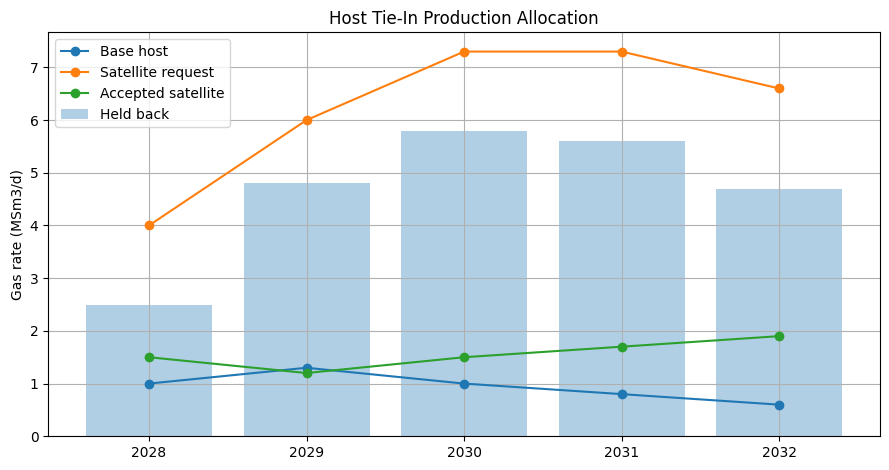

In [6]:
fig, ax = plt.subplots()
ax.plot(results_df["Year"], results_df["Base gas (MSm3/d)"], marker="o", label="Base host")
ax.plot(results_df["Year"], results_df["Satellite request (MSm3/d)"], marker="o", label="Satellite request")
ax.plot(results_df["Year"], results_df["Accepted satellite (MSm3/d)"], marker="o", label="Accepted satellite")
ax.bar(results_df["Year"], results_df["Held back gas (MSm3/d)"], alpha=0.35, label="Held back")
ax.set_ylabel("Gas rate (MSm3/d)")
ax.set_title("Host Tie-In Production Allocation")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "host_tie_in_production_allocation.png", dpi=150)
plt.show()

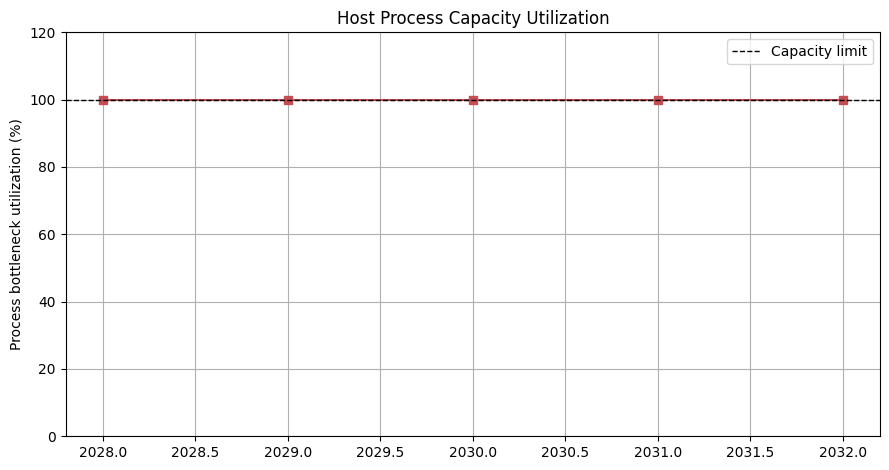

In [7]:
fig, ax = plt.subplots()
ax.plot(results_df["Year"], results_df["Process utilization (%)"], marker="s", color="#C44E52")
ax.axhline(100.0, color="black", linestyle="--", linewidth=1.0, label="Capacity limit")
ax.set_ylabel("Process bottleneck utilization (%)")
ax.set_title("Host Process Capacity Utilization")
ax.set_ylim(0, max(120.0, results_df["Process utilization (%)"].max() * 1.1))
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "host_tie_in_capacity_utilization.png", dpi=150)
plt.show()

## 3. Debottleneck Decision

The planner converts deferred value into a simple investment screen. A positive NPV suggests that the bottleneck deserves a more detailed equipment-specific study.

,Bottleneck,CAPEX (MUSD),Recovered value (MUSD),NPV (MUSD),Payback (years),Recommended
0,Host Feed,120.0,867.99,747.99,0.69,True


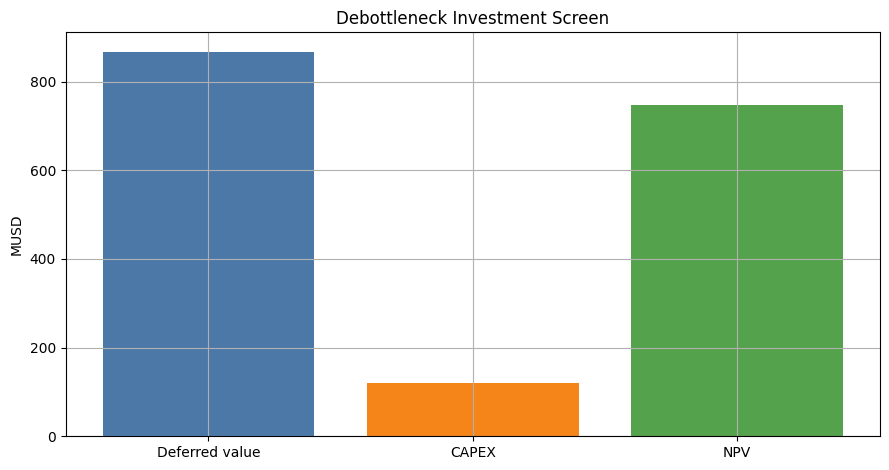

In [8]:
decision_rows = []
for decision in result.getDebottleneckDecisions():
    decision_rows.append({
        "Bottleneck": str(decision.getBottleneckName()),
        "CAPEX (MUSD)": decision.getCapexMusd(),
        "Recovered value (MUSD)": decision.getRecoveredValueMusd(),
        "NPV (MUSD)": decision.getNpvMusd(),
        "Payback (years)": decision.getPaybackYears(),
        "Recommended": bool(decision.isRecommended()),
    })

decisions_df = pd.DataFrame(decision_rows)
display(decisions_df.round(2))

fig, ax = plt.subplots()
if not decisions_df.empty:
    ax.bar(["Deferred value", "CAPEX", "NPV"], [
        decisions_df.loc[0, "Recovered value (MUSD)"],
        decisions_df.loc[0, "CAPEX (MUSD)"],
        decisions_df.loc[0, "NPV (MUSD)"],
    ], color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("MUSD")
ax.set_title("Debottleneck Investment Screen")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "host_tie_in_debottleneck_value.png", dpi=150)
plt.show()

## Interpretation

This case is controlled by the host feed process capacity rather than the host nameplate gas capacity. The result table shows how deferred satellite production accumulates when the process bottleneck is active. The debottleneck screen is deliberately simple; use the identified bottleneck to launch a more detailed compressor, separator, heat-exchanger, produced-water, or export-system design case.